In [28]:
# Loading the dataset using pandas

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('customer_shopping_behavior.csv')

In [29]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [31]:
# Summary statistics using .describe()
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [32]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [33]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [34]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [35]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [36]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [37]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [38]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [39]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [40]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [41]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [42]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [43]:
#Discount Effectiveness
discount_analysis = (
    df.groupby("discount_applied")
      .agg(
          customers=("customer_id", "count"),
          avg_purchase=("purchase_amount", "mean"),
          total_revenue=("purchase_amount", "sum")
      )
)

discount_analysis

,customers,avg_purchase,total_revenue
discount_applied,,,
No,2223,60.130454,133670
Yes,1677,59.279070,99411


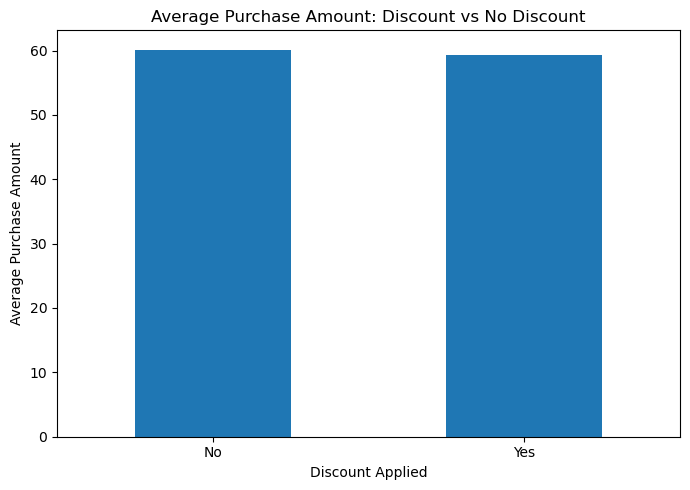

In [44]:
discount_analysis["avg_purchase"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Purchase Amount: Discount vs No Discount")
plt.xlabel("Discount Applied")
plt.ylabel("Average Purchase Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [45]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)

In [46]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [47]:
#Customer Value Score
df["value_score"] = (
    df["purchase_amount"] *
    (df["previous_purchases"] + 1)
)

high_value = (
    df.sort_values("value_score", ascending=False)
      [["customer_id",
        "purchase_amount",
        "previous_purchases",
        "value_score"]]
      .head(20)
)

high_value

,customer_id,purchase_amount,previous_purchases,value_score
455,456,100,50,5100
992,993,99,50,5049
1847,1848,100,49,5000
1737,1738,98,50,4998
885,886,99,49,4950
3746,3747,99,49,4950
2271,2272,99,49,4950
2484,2485,97,50,4947
2229,2230,97,50,4947
2842,2843,100,48,4900


In [48]:
#Frequency vs Purchase Amount
frequency_analysis = (
    df.groupby("frequency_of_purchases")
      .agg(
          customers=("customer_id", "count"),
          avg_purchase=("purchase_amount", "mean"),
          total_revenue=("purchase_amount", "sum")
      )
      .sort_values("avg_purchase", ascending=False)
)

frequency_analysis

,customers,avg_purchase,total_revenue
frequency_of_purchases,,,
Bi-Weekly,547,60.694698,33200
Annually,572,60.173077,34419
Every 3 Months,584,60.082192,35088
Quarterly,563,59.984014,33771
Monthly,553,59.330922,32810
Fortnightly,542,59.053506,32007
Weekly,539,58.972171,31786


In [49]:
#Product Performance Matrix
product_analysis = (
    df.groupby("item_purchased")
      .agg(
          orders=("customer_id", "count"),
          revenue=("purchase_amount", "sum"),
          avg_purchase=("purchase_amount", "mean"),
          avg_rating=("review_rating", "mean")
      )
      .sort_values("revenue", ascending=False)
)

product_analysis

,orders,revenue,avg_purchase,avg_rating
item_purchased,,,,
Blouse,171,10410,60.877193,3.680702
Shirt,169,10332,61.136095,3.622485
Dress,166,10320,62.168675,3.749398
Pants,171,10090,59.005848,3.720468
Jewelry,171,10010,58.538012,3.759064
Sunglasses,161,9649,59.931677,3.752174
Belt,161,9635,59.844720,3.763975
Scarf,157,9561,60.898089,3.707006
Sweater,164,9462,57.695122,3.759756


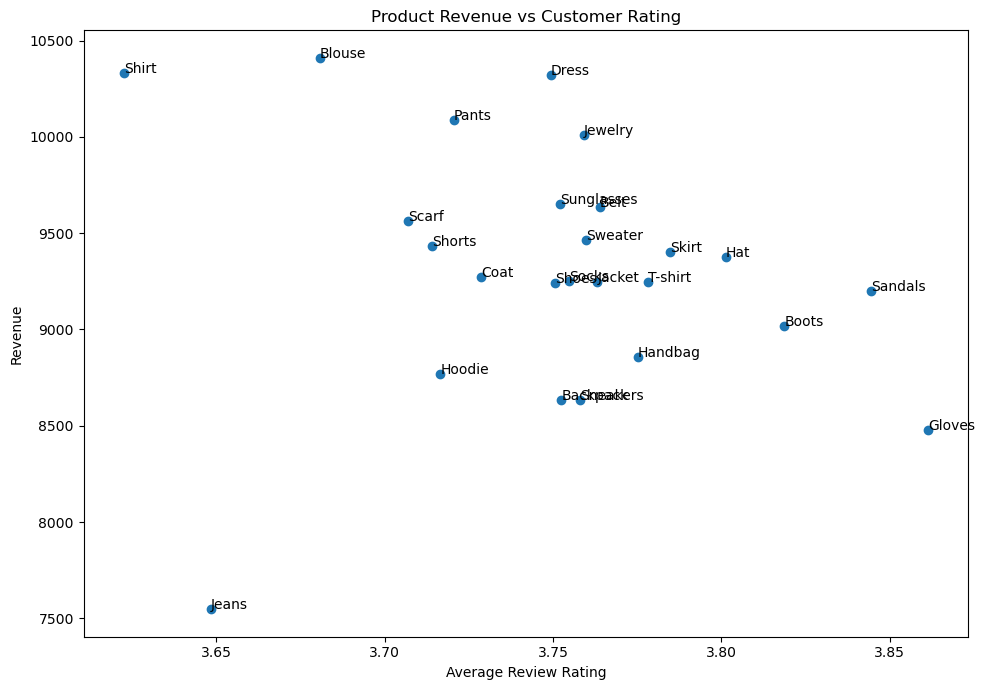

In [50]:
plt.figure(figsize=(10,7))

plt.scatter(
    product_analysis["avg_rating"],
    product_analysis["revenue"]
)

for product, row in product_analysis.iterrows():
    plt.annotate(
        product,
        (row["avg_rating"], row["revenue"])
    )

plt.xlabel("Average Review Rating")
plt.ylabel("Revenue")
plt.title("Product Revenue vs Customer Rating")
plt.tight_layout()
plt.show()

In [52]:
category_analysis = (
    df.groupby("category")
      .agg(
          orders=("customer_id", "count"),
          revenue=("purchase_amount", "sum"),
          avg_purchase=("purchase_amount", "mean"),
          rating=("review_rating", "mean")
      )
      .sort_values("revenue", ascending=False)
)

category_analysis

,orders,revenue,avg_purchase,rating
category,,,,
Clothing,1737,104264,60.025331,3.721301
Accessories,1240,74200,59.838710,3.770242
Footwear,599,36093,60.255426,3.793823
Outerwear,324,18524,57.172840,3.745988


In [53]:
subscription_analysis = (
    df.groupby("subscription_status")
      .agg(
          customers=("customer_id", "count"),
          avg_purchase=("purchase_amount", "mean"),
          avg_previous_purchases=("previous_purchases", "mean"),
          avg_rating=("review_rating", "mean")
      )
)

subscription_analysis

,customers,avg_purchase,avg_previous_purchases,avg_rating
subscription_status,,,,
No,2847,59.865121,25.080436,3.751001
Yes,1053,59.491928,26.084520,3.747483


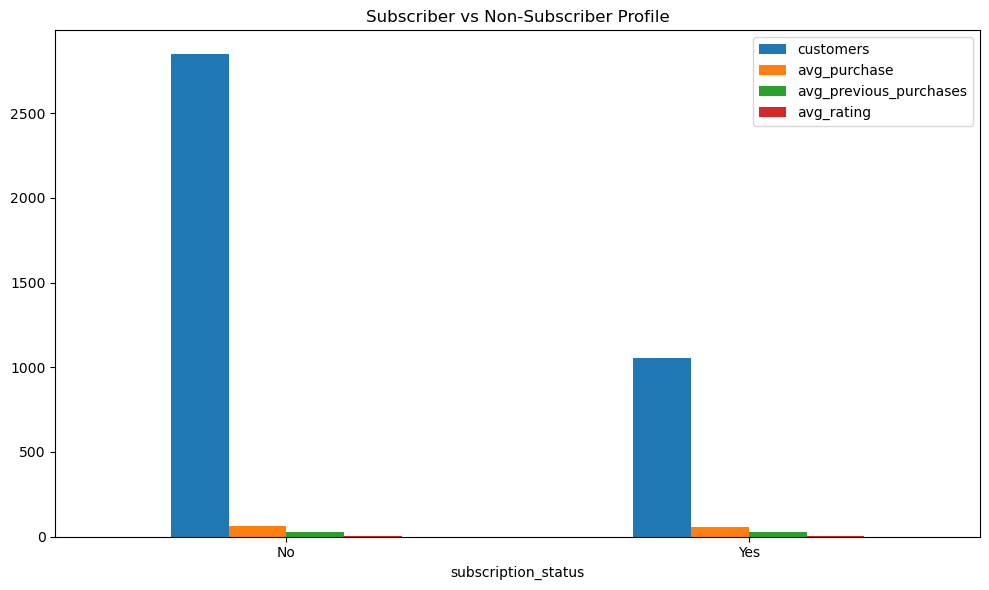

In [54]:
subscription_analysis.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Subscriber vs Non-Subscriber Profile")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [55]:
#Correlation Analysis-(to identify relationships worth investigating further)
numeric_cols = [
    "age",
    "purchase_amount",
    "review_rating",
    "previous_purchases"
]

correlation = df[numeric_cols].corr()

correlation

,age,purchase_amount,review_rating,previous_purchases
age,1.000000,-0.010424,-0.024463,0.040445
purchase_amount,-0.010424,1.000000,0.029659,0.008063
review_rating,-0.024463,0.029659,1.000000,0.003555
previous_purchases,0.040445,0.008063,0.003555,1.000000


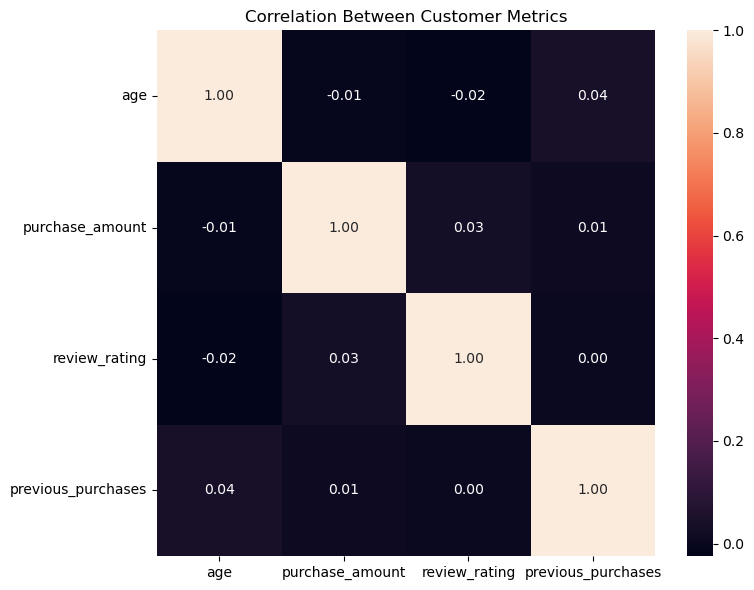

In [56]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Customer Metrics")
plt.tight_layout()
plt.show()

In [58]:
#Age-Based Customer Behavior
df["Age Group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

age_analysis = (
    df.groupby("Age Group", observed=True)
      .agg(
          customers=("customer_id", "count"),
          avg_purchase=("purchase_amount", "mean"),
          revenue=("purchase_amount", "sum"),
          avg_rating=("review_rating", "mean")
      )
)

age_analysis

,customers,avg_purchase,revenue,avg_rating
Age Group,,,,
18-25,571,60.647986,34630,3.819089
26-35,742,59.760108,44342,3.738005
36-45,729,59.305898,43234,3.747737
46-55,753,60.583001,45619,3.714874
56-65,750,59.136000,44352,3.744533
66+,355,58.884507,20904,3.755211


In [59]:
#Discount with Subscription Matrix
discount_subscription = pd.crosstab(
    df["subscription_status"],
    df["discount_applied"],
    normalize="index"
) * 100

discount_subscription

discount_applied,No,Yes
subscription_status,,
No,78.082192,21.917808
Yes,0.000000,100.000000


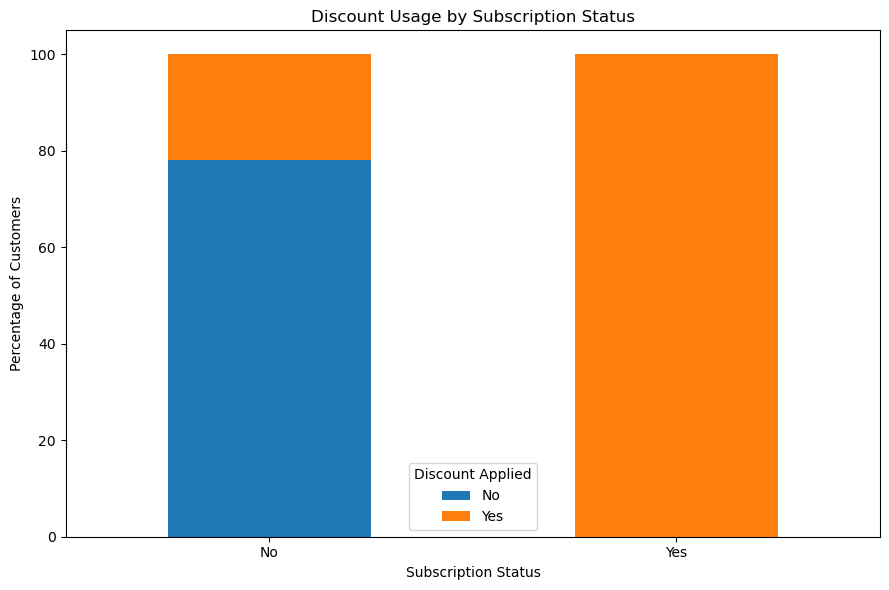

In [60]:
discount_subscription.plot(
    kind="bar",
    stacked=True,
    figsize=(9,6)
)

plt.title("Discount Usage by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Discount Applied")
plt.tight_layout()
plt.show()

In [63]:
df["customer_value_score"] = (
    df["purchase_amount"] *
    (df["previous_purchases"] + 1)
)

target_customers = df[
    (df["customer_value_score"] >=
     df["customer_value_score"].quantile(0.75))
    &
    (df["subscription_status"] == "No")
]

target_customers[
    [
        "customer_id",
        "purchase_amount",
        "previous_purchases",
        "review_rating",
        "subscription_status",
        "discount_applied",
        "customer_value_score"
    ]
].head(20)

,customer_id,purchase_amount,previous_purchases,review_rating,subscription_status,discount_applied,customer_value_score
1054,1055,96,48,4.9,No,Yes,4704
1056,1057,64,42,2.9,No,Yes,2752
1068,1069,94,47,2.5,No,Yes,4512
1069,1070,81,33,4.3,No,Yes,2754
1070,1071,75,50,3.3,No,Yes,3825
1071,1072,81,46,2.6,No,Yes,3807
1072,1073,92,34,3.7,No,Yes,3220
1073,1074,96,33,4.0,No,Yes,3264
1074,1075,71,45,2.6,No,Yes,3266
1076,1077,72,47,2.9,No,Yes,3456


## Code for MySQL

In [18]:
import sys
!{sys.executable} -m pip install pymysql cryptography sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [19]:
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "11111"
host = "localhost"
port = "3306"
database = "customer_behavior"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "customer"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM customer LIMIT 5;", engine)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365


## Code for MS SQL Server

In [20]:
#!pip install pyodbc sqlalchemy 

In [21]:
"""# Install required libraries

from sqlalchemy import create_engine
from urllib.parse import quote_plus

# SQL Server connection
username = "sa"
password = "your_password"
host = "localhost"
port = "1433"
database = "customer_behavior"

# Note: requires Microsoft ODBC Driver installed separately on your machine
driver = quote_plus("ODBC Driver 17 for SQL Server")
engine = create_engine(f"mssql+pyodbc://{username}:{password}@{host},{port}/{database}?driver={driver}")

# Write DataFrame to SQL Server
df.to_sql("customer", engine, if_exists="replace", index=False)

# Read back sample (SQL Server uses TOP instead of LIMIT)
pd.read_sql("SELECT TOP 5 * FROM customer;", engine)"""

'# Install required libraries\n\nfrom sqlalchemy import create_engine\nfrom urllib.parse import quote_plus\n\n# SQL Server connection\nusername = "sa"\npassword = "your_password"\nhost = "localhost"\nport = "1433"\ndatabase = "customer_behavior"\n\n# Note: requires Microsoft ODBC Driver installed separately on your machine\ndriver = quote_plus("ODBC Driver 17 for SQL Server")\nengine = create_engine(f"mssql+pyodbc://{username}:{password}@{host},{port}/{database}?driver={driver}")\n\n# Write DataFrame to SQL Server\ndf.to_sql("customer", engine, if_exists="replace", index=False)\n\n# Read back sample (SQL Server uses TOP instead of LIMIT)\npd.read_sql("SELECT TOP 5 * FROM customer;", engine)'